# ANN Regression Imports

This cell imports the functions needed for the ANN regression workflow.

### What is happening
- `train_ann_regression_model` trains the ANN model using PyTorch.
- `summarize_ann_results` loads saved ANN outputs for inspection.
- `find_project_root` and `resolve_project_path` handle file paths.

### Main files involved later
- `data/processed/train.csv`
- `data/processed/test.csv`
- `artifacts/ann/...`
- `figures/regression/ann_loss_curve.png`
- `reports/ann_evaluation_report.md`

In [1]:
import pandas as pd

from src.modeling.train_ann import train_ann_regression_model
from src.modeling.evaluate_ann import summarize_ann_results
from src.utils.paths import find_project_root, resolve_project_path

# Resolve Project Root

This cell identifies the root project directory for the ANN notebook.

### What is happening
- The root path is detected automatically.
- This ensures all ANN artifacts are saved to the correct folders.

### Output locations used later
- `artifacts/ann/`
- `figures/regression/`
- `reports/`

In [2]:
project_root = find_project_root()
project_root

WindowsPath('F:/DATA SCIENCE/Projects/Diamond Dynamics Price Prediction and Market Segmentation')

# Train the ANN Regression Model

This is the main ANN training cell.

### What is happening
- The saved train/test datasets are loaded.
- A preprocessing pipeline is fitted for ANN input.
- Features are transformed into numeric arrays suitable for PyTorch.
- A feedforward ANN regressor is trained on the training data.
- Validation loss is tracked during training.
- Final predictions are generated on the test set.
- Evaluation metrics are computed.

### Metrics computed
- MAE
- MSE
- RMSE
- R²

### Files created

#### ANN artifacts
- `artifacts/ann/ann_regressor.pt`
- `artifacts/ann/ann_preprocessor.pkl`
- `artifacts/ann/ann_training_history.csv`
- `artifacts/ann/ann_metrics.csv`
- `artifacts/ann/ann_predictions.csv`
- `artifacts/ann/ann_model_metadata.yaml`

#### Figure
- `figures/regression/ann_loss_curve.png`

#### Report
- `reports/ann_evaluation_report.md`

### Why this matters
This cell completes the neural-network-based regression experiment for the project.

In [3]:
ann_results = train_ann_regression_model(project_root)
ann_results["metrics"]

2026-03-23 00:44:23,852 | INFO | src.data.split_data | Loading regression modeling dataset...
2026-03-23 00:44:23,949 | INFO | src.data.split_data | Splitting dataset into train/test...
2026-03-23 00:44:23,985 | INFO | src.data.split_data | Saving train/test splits...
2026-03-23 00:44:24,206 | INFO | src.data.split_data | Train/test split completed.
2026-03-23 00:44:24,263 | INFO | src.modeling.train_ann | Fitting ANN preprocessor...
2026-03-23 00:44:29,776 | INFO | src.modeling.train_ann | Starting PyTorch ANN training...
2026-03-23 00:44:33,932 | INFO | src.modeling.train_ann | Epoch 1/120 | train_loss=3.557776 | val_loss=0.051598 | lr=0.001000
2026-03-23 00:44:36,221 | INFO | src.modeling.train_ann | Epoch 2/120 | train_loss=0.281562 | val_loss=0.054867 | lr=0.001000
2026-03-23 00:44:38,467 | INFO | src.modeling.train_ann | Epoch 3/120 | train_loss=0.249124 | val_loss=0.063285 | lr=0.001000
2026-03-23 00:44:40,683 | INFO | src.modeling.train_ann | Epoch 4/120 | train_loss=0.233821 |

{'mae': 299.1327285370563,
 'mse': 342298.0356251489,
 'rmse': 585.0624202810748,
 'r2': 0.9784675171275811}

# Load and Summarize Saved ANN Results

This cell reloads the saved ANN artifacts and displays the ANN metrics table.

### What is happening
- The saved PyTorch ANN model checkpoint is loaded.
- The training history CSV is loaded.
- The ANN metrics CSV is loaded.
- A summary dictionary is returned for notebook inspection.

### Files being read
- `artifacts/ann/ann_regressor.pt`
- `artifacts/ann/ann_training_history.csv`
- `artifacts/ann/ann_metrics.csv`

### Why this matters
This allows you to inspect ANN results without retraining the model again.

In [4]:
summary = summarize_ann_results(project_root)
summary["metrics_df"]

,model_name,mae,mse,rmse,r2
0,ann_regressor_pytorch,299.132729,342298.035625,585.06242,0.978468


# Inspect ANN Training History

This cell displays the first few rows of the ANN training history.

### What is happening
The history dataframe contains epoch-level training details such as:
- epoch number,
- training loss,
- validation loss,
- learning rate.

### File where this is stored
- `artifacts/ann/ann_training_history.csv`

### Why this matters
This helps you check:
- whether training was stable,
- whether the model improved over time,
- whether early stopping likely occurred at a sensible point.

In [5]:
summary["history_df"].head()

,epoch,loss,val_loss,learning_rate
0,1,3.557776,0.051598,0.001
1,2,0.281562,0.054867,0.001
2,3,0.249124,0.063285,0.001
3,4,0.233821,0.066662,0.001
4,5,0.201101,0.059834,0.001


# Display ANN Loss Curve

This cell displays the saved ANN loss curve image.

### What is happening
- The figure showing training loss and validation loss across epochs is loaded and displayed.

### File being displayed
- `figures/regression/ann_loss_curve.png`

### Why this matters
This plot helps visually assess:
- convergence,
- possible overfitting,
- whether validation loss improved consistently during training.

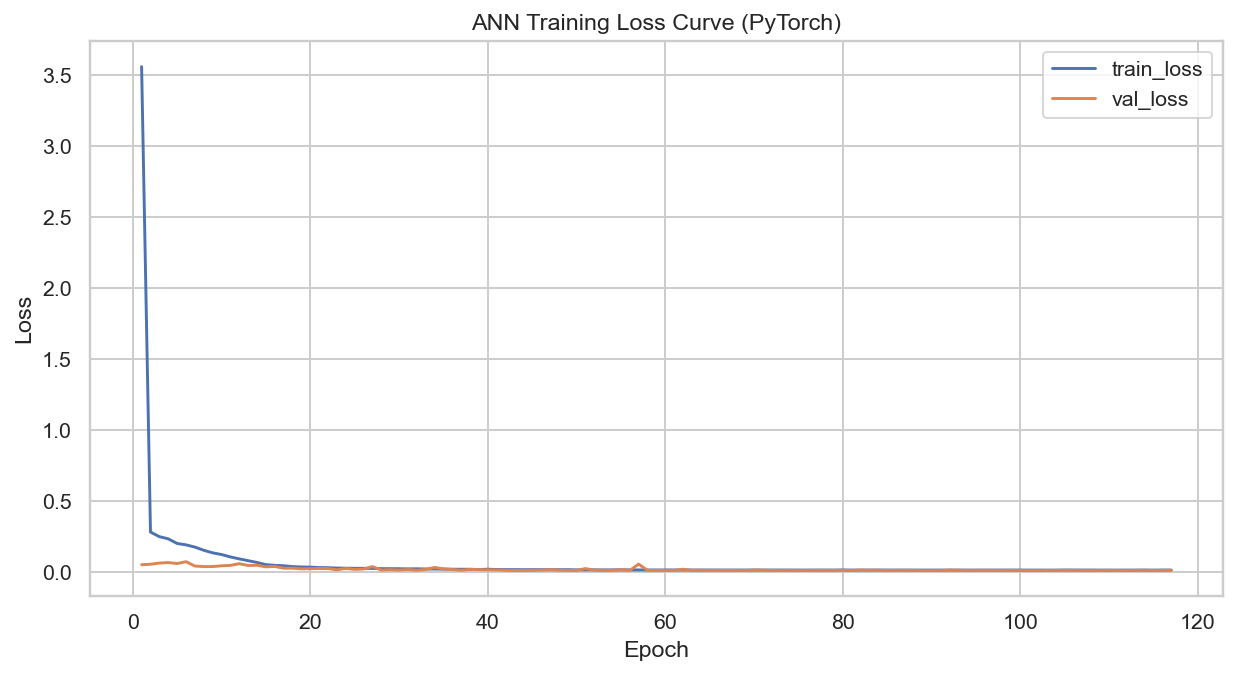

In [6]:
from IPython.display import Image, display

display(Image(filename=str(resolve_project_path(project_root, "figures/regression/ann_loss_curve.png"))))